In [2]:
# ============================================
# SDG Indicator Text Classification
# Member A: Data Pipeline Lead
# Tasks: EDA, Preprocessing, Feature Engineering, Experiment Tracking
# Dataset loaded from Google Drive
# ============================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required packages

!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud plotly openpyxl -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter

# For feature engineering
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All imports successful!")
print("Google Drive mounted at /content/drive")

Mounted at /content/drive
All imports successful!
Google Drive mounted at /content/drive


In [3]:
# ============================================
# FIND YOUR DATASET FILES IN DRIVE
# ============================================

DRIVE_PATH = "/content/drive/MyDrive/SDG"

# Let's search for the files
import os

print("Searching for dataset files in your Drive...")
print("-" * 50)

# Search for Devex_train.csv
train_path = None
test_path = None

for root, dirs, files in os.walk('/content/drive/MyDrive/SDG'):
    for file in files:
        if file == 'Devex_train.csv':
            train_path = os.path.join(root, file)
            print(f" Found training file: {train_path}")
        elif file == 'Devex_test_questions.csv':
            test_path = os.path.join(root, file)
            print(f" Found test file: {test_path}")

if train_path is None or test_path is None:
    print("\n Files not found automatically!")
    print("\nPlease enter the paths manually:")
    print("Example: /content/drive/MyDrive/SDG/Devex_train.csv")

    train_path = input("Enter full path to Devex_train.csv: ").strip()
    test_path = input("Enter full path to Devex_test_questions.csv: ").strip()

# Load the data
print("\n" + "=" * 60)
print("LOADING DATASETS")
print("=" * 60)

train_df = pd.read_csv(train_path, encoding='latin1')
test_df = pd.read_csv(test_path, encoding='latin1')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nTraining columns: {train_df.columns.tolist()}")
print(f"Test columns: {test_df.columns.tolist()}")

# Display first few rows
print("\n" + "=" * 60)
print("FIRST 5 ROWS OF TRAINING DATA")
print("=" * 60)
train_df.head()

Searching for dataset files in your Drive...
--------------------------------------------------
 Found training file: /content/drive/MyDrive/SDG/Devex_train.csv
 Found test file: /content/drive/MyDrive/SDG/Devex_test_questions.csv

LOADING DATASETS
Training data shape: (2995, 15)
Test data shape: (998, 3)

Training columns: ['Unique ID', 'Type', 'Text', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']
Test columns: ['Unique ID', 'Type', 'Text']

FIRST 5 ROWS OF TRAINING DATA


,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display detailed dataset information
print("=" * 60)
print("DATASET DETAILS")
print("=" * 60)

print("\n--- Training Data Info ---")
train_df.info()

print("\n--- Missing Values ---")
print(f"Missing values in training: {train_df.isnull().sum().sum()}")
print(f"Missing values in test: {test_df.isnull().sum().sum()}")

# Show column names to understand structure
print("\n--- Column Names ---")
print("Training columns:")
for i, col in enumerate(train_df.columns):
    print(f"  {i+1}. {col}")

print("\nTest columns:")
for i, col in enumerate(test_df.columns):
    print(f"  {i+1}. {col}")

DATASET DETAILS

--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2995 entries, 0 to 2994
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unique ID  2995 non-null   int64  
 1   Type       2995 non-null   object 
 2   Text       2995 non-null   object 
 3   Label 1    2995 non-null   object 
 4   Label 2    1635 non-null   object 
 5   Label 3    738 non-null    object 
 6   Label 4    312 non-null    object 
 7   Label 5    142 non-null    object 
 8   Label 6    59 non-null     object 
 9   Label 7    21 non-null     object 
 10  Label 8    10 non-null     object 
 11  Label 9    4 non-null      object 
 12  Label 10   2 non-null      object 
 13  Label 11   0 non-null      float64
 14  Label 12   0 non-null      float64
dtypes: float64(2), int64(1), object(12)
memory usage: 351.1+ KB

--- Missing Values ---
Missing values in training: 30022
Missing values in test: 0

--- Column Names --

In [5]:
# ============================================
# IDENTIFY SDG INDICATOR COLUMNS
# ============================================

# First, let's see what columns look like
print("Checking column patterns...")

# Display first few column names to understand naming convention
print("\nFirst 20 column names from training data:")
for col in train_df.columns[:20]:
    print(f"  - {col}")

# The original code's approach to find `potential_indicators` based on column names or numeric values
# is not suitable for this dataset, as the actual indicators are *values* within the 'Label X' columns.
potential_indicators = []
print(f"\nFound {len(potential_indicators)} potential SDG indicator columns (based on column name patterns):")
if len(potential_indicators) > 0:
    for ind in potential_indicators[:15]:
        print(f"  - {ind}")
    if len(potential_indicators) > 15:
        print(f"  ... and {len(potential_indicators)-15} more")
else:
    print("  None found with column name pattern matching. Labels are likely embedded in 'Label X' columns.")
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"Numeric columns: {numeric_cols[:20]}")


# ============================================
# CRITICAL: MANUALLY IDENTIFY TARGET COLUMNS (ADAPTED FOR THIS DATASET)
# ============================================

print("\n" + "=" * 60)
print(" ACTION REQUIRED: Identify Target Columns (Adapted)")
print("=" * 60)
print("\nBased on the dataset structure, SDG indicators are embedded in 'Label 1' to 'Label 12' columns.")
print("We will extract unique indicator codes from these columns and create binary features.")

# Display all columns with their first few values to help identification
print("\n--- Sample values from each column ---")
for col in train_df.columns[:10]:  # Check first 10 columns
    unique_vals = train_df[col].unique()[:5]
    print(f"\nColumn: {col}")
    print(f"  Sample values: {unique_vals}")
    print(f"  Data type: {train_df[col].dtype}")

print("\n" + "=" * 60)
print("IDENTIFYING INDICATOR CODES FROM 'Label X' COLUMNS")
print("=" * 60)

# 1. Correct TEXT_COL identification
# Prioritize 'Text' with correct casing, then other common names
TEXT_COL = None
for col_name in ['Text', 'text', 'description', 'content', 'sentence', 'document', 'title', 'abstract']:
    if col_name in train_df.columns:
        TEXT_COL = col_name
        break

# Fallback to first object column if no standard text column names match, excluding 'Label X' columns
if TEXT_COL is None:
    for col_name in train_df.columns:
        if train_df[col_name].dtype == 'object' and not col_name.startswith('Label'):
            TEXT_COL = col_name
            break

print(f"\nIdentified text column: {TEXT_COL}")


# 2. Identify all unique SDG indicator codes from 'Label X' columns
label_columns = [col for col in train_df.columns if col.startswith('Label')]
unique_sdg_indicators_set = set()

for col in label_columns:
    if train_df[col].dtype == 'object': # Only process string columns
        for label_str in train_df[col].dropna().astype(str).unique(): # Ensure string type
            if ' - ' in label_str:
                indicator_code = label_str.split(' - ')[0].strip()
                unique_sdg_indicators_set.add(indicator_code)
            else:
                # If no delimiter, the entire string might be the indicator
                unique_sdg_indicators_set.add(label_str.strip())

SDG_INDICATORS = sorted(list(unique_sdg_indicators_set))

print(f"\nFound {len(SDG_INDICATORS)} unique SDG indicator codes:")
for i, ind in enumerate(SDG_INDICATORS[:10]):
    print(f"  {i+1}. {ind}")
if len(SDG_INDICATORS) > 10:
    print(f"  ... and {len(SDG_INDICATORS)-10} more")

# 3. Create binary indicator columns in train_df
# This will allow subsequent cells to use train_df[SDG_INDICATORS] directly.
for indicator_code in SDG_INDICATORS:
    train_df[indicator_code] = 0 # Initialize with 0

# Optimized population of binary target columns
for label_col in label_columns:
    if train_df[label_col].dtype == 'object': # Ensure column is of string type
        for idx, label_str in train_df[label_col].dropna().items():
            if ' - ' in label_str:
                extracted_code = label_str.split(' - ')[0].strip()
            else:
                extracted_code = label_str.strip()

            if extracted_code in SDG_INDICATORS:
                train_df.loc[idx, extracted_code] = 1


print(f"\n{'='*60}")
print(f"FINAL INDICATOR COLUMNS (as new binary columns in train_df): {len(SDG_INDICATORS)} indicators")
print('='*60)
for i, ind in enumerate(SDG_INDICATORS[:10]):
    print(f"  {i+1}. {ind}")
if len(SDG_INDICATORS) > 10:
    print(f"  ... and {len(SDG_INDICATORS)-10} more")

# Verify we have both text and indicators
if TEXT_COL is None:
    raise ValueError("Could not identify text column! Please check your dataset.")
if len(SDG_INDICATORS) == 0:
    raise ValueError("Could not identify indicator columns! Please check your dataset.")


Checking column patterns...

First 20 column names from training data:
  - Unique ID
  - Type
  - Text
  - Label 1
  - Label 2
  - Label 3
  - Label 4
  - Label 5
  - Label 6
  - Label 7
  - Label 8
  - Label 9
  - Label 10
  - Label 11
  - Label 12

Found 0 potential SDG indicator columns (based on column name patterns):
  None found with column name pattern matching. Labels are likely embedded in 'Label X' columns.
Numeric columns: ['Unique ID', 'Label 11', 'Label 12']

 ACTION REQUIRED: Identify Target Columns (Adapted)

Based on the dataset structure, SDG indicators are embedded in 'Label 1' to 'Label 12' columns.
We will extract unique indicator codes from these columns and create binary features.

--- Sample values from each column ---

Column: Unique ID
  Sample values: [ 12555  14108  23168 219512 274093]
  Data type: int64

Column: Type
  Sample values: ['Grant' 'Organization' 'Contract' 'Tender' 'Funding Info']
  Data type: object

Column: Text
  Sample values: ['Centers of B

BASIC STATISTICS
Total samples: 2995
Number of SDG 3 indicators: 27
Missing values in text column: 0

LABEL DISTRIBUTION (Top 10 most frequent indicators)
3.b.2: 1040 samples (34.72%)
3.8.1: 529 samples (17.66%)
3.4.1: 483 samples (16.13%)
3.b.3: 394 samples (13.16%)
3.3.1: 371 samples (12.39%)
3.2.1: 249 samples (8.31%)
3.c.1: 232 samples (7.75%)
3.1.1: 218 samples (7.28%)
3.9.2: 217 samples (7.25%)
3.d.1: 217 samples (7.25%)


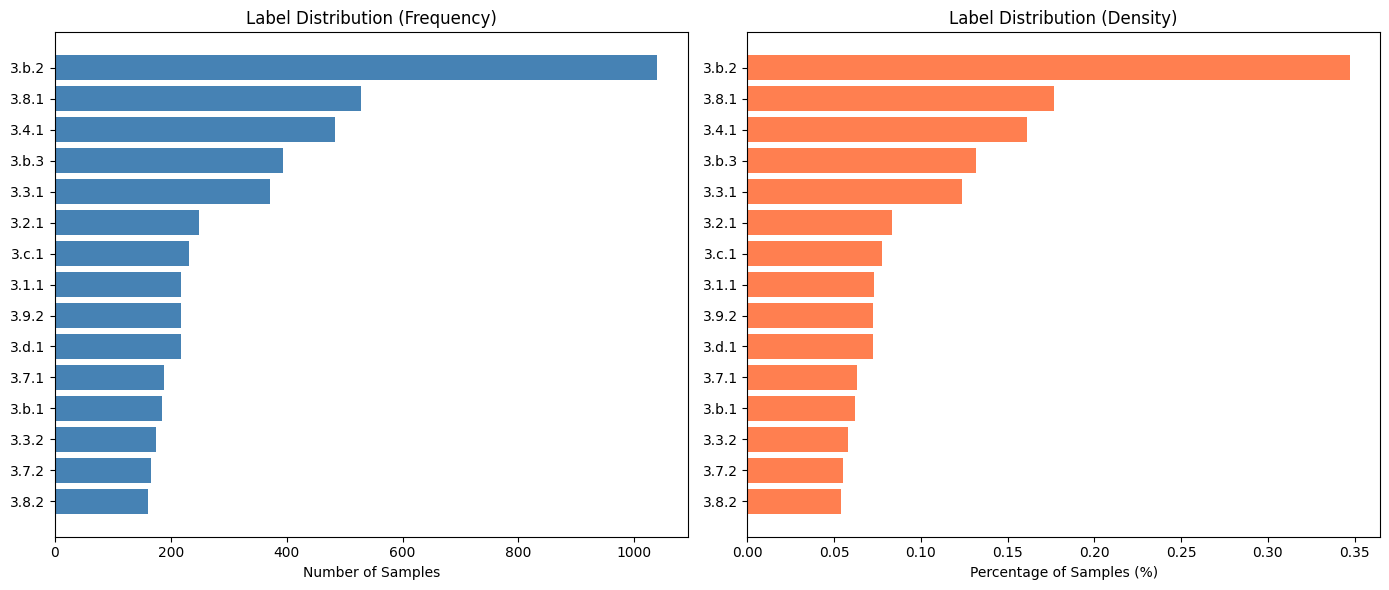


MULTI-LABEL STATISTICS
Average labels per document: 1.97
Documents with zero labels: 0
Documents with exactly 1 label: 1362
Documents with 2+ labels: 1633


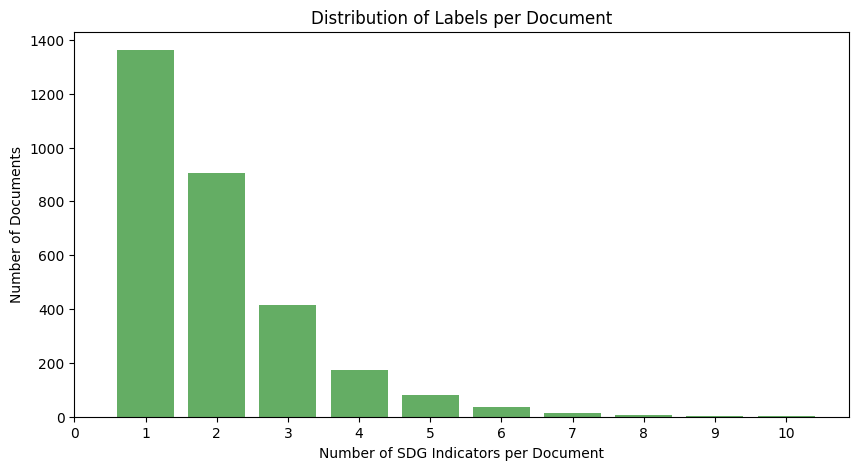

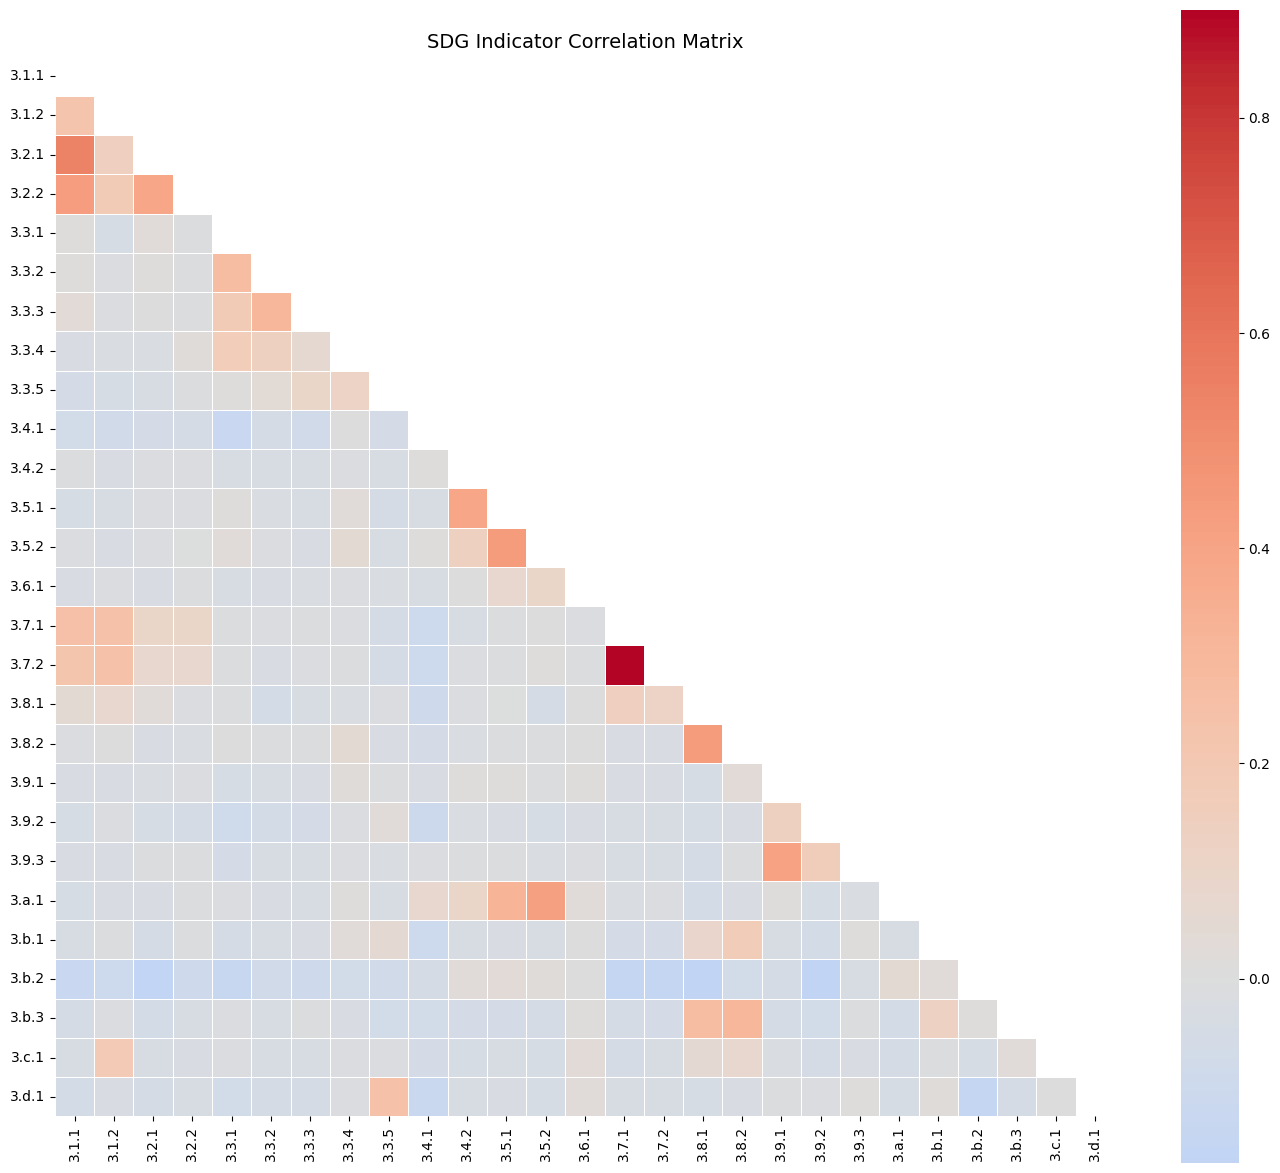


Top 10 most correlated indicator pairs:
1. 3.7.1 ↔ 3.7.2: 0.900
2. 3.1.1 ↔ 3.2.1: 0.544
3. 3.5.1 ↔ 3.5.2: 0.443
4. 3.8.1 ↔ 3.8.2: 0.437
5. 3.1.1 ↔ 3.2.2: 0.429
6. 3.5.2 ↔ 3.a.1: 0.417
7. 3.9.1 ↔ 3.9.3: 0.413
8. 3.2.1 ↔ 3.2.2: 0.390
9. 3.4.2 ↔ 3.5.1: 0.387
10. 3.5.1 ↔ 3.a.1: 0.320


In [6]:
# ============================================
# COMPREHENSIVE EDA
# ============================================

# 5.1 Basic Statistics
print("=" * 60)
print("BASIC STATISTICS")
print("=" * 60)

print(f"Total samples: {len(train_df)}")
print(f"Number of SDG 3 indicators: {len(SDG_INDICATORS)}")
print(f"Missing values in text column: {train_df[TEXT_COL].isna().sum()}")

# 5.2 Label Distribution Analysis
label_counts = train_df[SDG_INDICATORS].sum().sort_values(ascending=False)
label_density = train_df[SDG_INDICATORS].mean().sort_values(ascending=False)

print("\n" + "=" * 60)
print("LABEL DISTRIBUTION (Top 10 most frequent indicators)")
print("=" * 60)
for idx, (indicator, count) in enumerate(label_counts.head(10).items()):
    percentage = (count / len(train_df)) * 100
    print(f"{indicator}: {count} samples ({percentage:.2f}%)")

# Check for empty labels (indicators with zero samples)
zero_labels = label_counts[label_counts == 0].index.tolist()
if zero_labels:
    print(f"\n Warning: {len(zero_labels)} indicators have ZERO positive samples:")
    for label in zero_labels:
        print(f"  - {label}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot of label counts
axes[0].barh(label_counts.head(15).index, label_counts.head(15).values, color='steelblue')
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('Label Distribution (Frequency)')
axes[0].invert_yaxis()

# Bar plot of label density
axes[1].barh(label_density.head(15).index, label_density.head(15).values, color='coral')
axes[1].set_xlabel('Percentage of Samples (%)')
axes[1].set_title('Label Distribution (Density)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.3 Multi-label Analysis
label_matrix = train_df[SDG_INDICATORS].values
samples_per_label_count = label_matrix.sum(axis=1)
labels_per_sample = samples_per_label_count

print("\n" + "=" * 60)
print("MULTI-LABEL STATISTICS")
print("=" * 60)
print(f"Average labels per document: {labels_per_sample.mean():.2f}")
print(f"Documents with zero labels: {(labels_per_sample == 0).sum()}")
print(f"Documents with exactly 1 label: {(labels_per_sample == 1).sum()}")
print(f"Documents with 2+ labels: {(labels_per_sample >= 2).sum()}")

# Distribution of labels per document
fig, ax = plt.subplots(figsize=(10, 5))
unique_counts, counts = np.unique(labels_per_sample, return_counts=True)
ax.bar(unique_counts, counts, color='forestgreen', alpha=0.7)
ax.set_xlabel('Number of SDG Indicators per Document')
ax.set_ylabel('Number of Documents')
ax.set_title('Distribution of Labels per Document')
ax.set_xticks(range(int(max(unique_counts)) + 1))
plt.savefig('labels_per_document.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.4 Label Correlation Matrix
label_corr = train_df[SDG_INDICATORS].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(label_corr, dtype=bool))
sns.heatmap(label_corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, square=True, linewidths=0.5)
plt.title('SDG Indicator Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('label_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Find most correlated indicator pairs
corr_pairs = []
for i in range(len(SDG_INDICATORS)):
    for j in range(i+1, len(SDG_INDICATORS)):
        corr_pairs.append((SDG_INDICATORS[i], SDG_INDICATORS[j], label_corr.iloc[i, j]))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("\nTop 10 most correlated indicator pairs:")
for i, (ind1, ind2, corr) in enumerate(corr_pairs[:10]):
    print(f"{i+1}. {ind1} ↔ {ind2}: {corr:.3f}")

In [7]:
# ============================================
# LABEL CARDINALITY ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("MOST COMMON LABEL COMBINATIONS")
print("=" * 60)

from collections import Counter

# Find most frequent label combinations
label_combinations = []
for i in range(len(train_df)):
    labels_present = [SDG_INDICATORS[j] for j in range(len(SDG_INDICATORS))
                      if train_df[SDG_INDICATORS].iloc[i, j] == 1]
    if labels_present:
        label_combinations.append(tuple(sorted(labels_present)))

common_combos = Counter(label_combinations).most_common(10)

print("\nTop 10 most frequent label combinations:")
for i, (combo, count) in enumerate(common_combos, 1):
    print(f"{i:2}. {combo}: {count} documents ({count/len(train_df)*100:.1f}%)")

# Label set size distribution (how many docs have each number of labels)
print("\n" + "=" * 60)
print("LABEL SET SIZE DISTRIBUTION")
print("=" * 60)
label_size_dist = Counter([len(combo) for combo in label_combinations])
for size in sorted(label_size_dist.keys()):
    count = label_size_dist[size]
    print(f"Documents with {size} label(s): {count} ({count/len(train_df)*100:.1f}%)")


MOST COMMON LABEL COMBINATIONS

Top 10 most frequent label combinations:
 1. ('3.b.2',): 431 documents (14.4%)
 2. ('3.4.1',): 209 documents (7.0%)
 3. ('3.9.2',): 119 documents (4.0%)
 4. ('3.3.1',): 116 documents (3.9%)
 5. ('3.4.1', '3.b.2'): 94 documents (3.1%)
 6. ('3.b.2', '3.b.3'): 79 documents (2.6%)
 7. ('3.d.1',): 79 documents (2.6%)
 8. ('3.3.3',): 55 documents (1.8%)
 9. ('3.c.1',): 51 documents (1.7%)
10. ('3.8.1',): 49 documents (1.6%)

LABEL SET SIZE DISTRIBUTION
Documents with 1 label(s): 1362 (45.5%)
Documents with 2 label(s): 905 (30.2%)
Documents with 3 label(s): 416 (13.9%)
Documents with 4 label(s): 173 (5.8%)
Documents with 5 label(s): 81 (2.7%)
Documents with 6 label(s): 37 (1.2%)
Documents with 7 label(s): 12 (0.4%)
Documents with 8 label(s): 5 (0.2%)
Documents with 9 label(s): 2 (0.1%)
Documents with 10 label(s): 2 (0.1%)


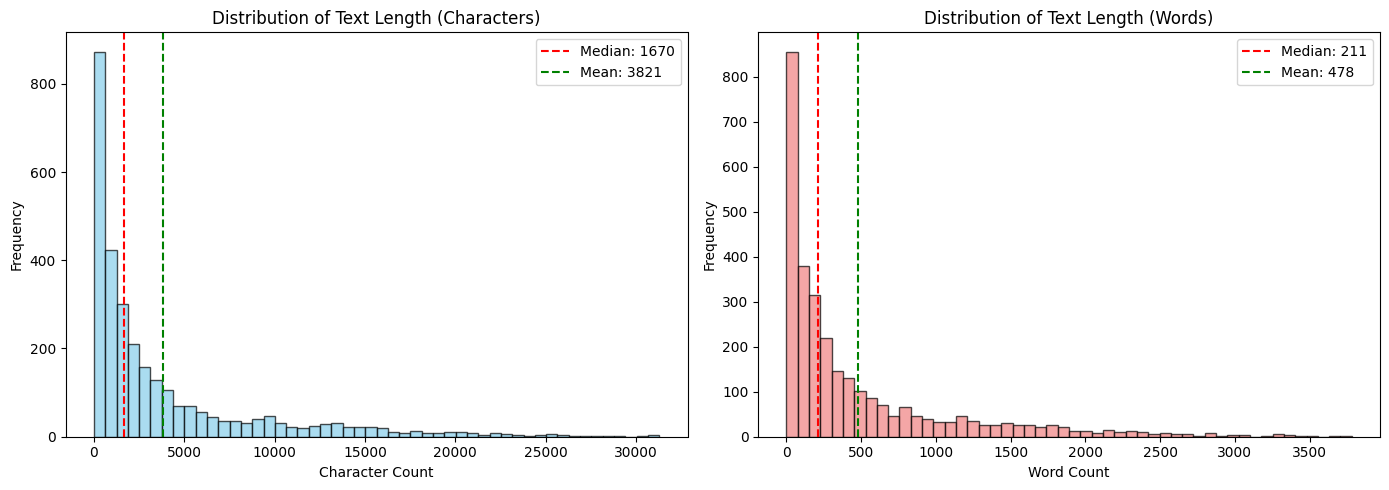


TEXT LENGTH STATISTICS
Character count - Min: 13, Max: 31277
Character count - Mean: 3820.61, Median: 1670.00
Word count - Min: 2, Max: 3781
Word count - Mean: 477.75, Median: 211.00

Very short texts (<5 words): 90
Very long texts (>500 words): 889

SAMPLE TEXTS FOR EACH LABEL COUNT

 Document with 1 label(s):
   Labels: ['3.b.2']
   Text preview: Research on Regenerative Medicine <h2><strong>Introduction</strong></h2>    <p>Supports translation of fundamental discoveries toward benefits to human health.</p>    <p>The translation of the burgeoning knowledge in regenerative medicine into new tr...

 Document with 2 label(s):
   Labels: ['3.b.2', '3.c.1']
   Text preview: Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate...

 Document with 3 label(s):
   Labels: ['3.3.2', '3.b.2', '3.b.3'

In [8]:
# ============================================
# TEXT ANALYSIS
# ============================================

# Handle missing text values
train_df[TEXT_COL] = train_df[TEXT_COL].fillna("").astype(str)

# 6.1 Text Length Analysis
train_df['text_length'] = train_df[TEXT_COL].apply(len)
train_df['word_count'] = train_df[TEXT_COL].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Length (Characters)')
axes[0].axvline(train_df['text_length'].median(), color='red', linestyle='--',
                label=f'Median: {train_df["text_length"].median():.0f}')
axes[0].axvline(train_df['text_length'].mean(), color='green', linestyle='--',
                label=f'Mean: {train_df["text_length"].mean():.0f}')
axes[0].legend()

axes[1].hist(train_df['word_count'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Text Length (Words)')
axes[1].axvline(train_df['word_count'].median(), color='red', linestyle='--',
                label=f'Median: {train_df["word_count"].median():.0f}')
axes[1].axvline(train_df['word_count'].mean(), color='green', linestyle='--',
                label=f'Mean: {train_df["word_count"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical summary
print("\n" + "=" * 60)
print("TEXT LENGTH STATISTICS")
print("=" * 60)
print(f"Character count - Min: {train_df['text_length'].min()}, Max: {train_df['text_length'].max()}")
print(f"Character count - Mean: {train_df['text_length'].mean():.2f}, Median: {train_df['text_length'].median():.2f}")
print(f"Word count - Min: {train_df['word_count'].min()}, Max: {train_df['word_count'].max()}")
print(f"Word count - Mean: {train_df['word_count'].mean():.2f}, Median: {train_df['word_count'].median():.2f}")

# 6.2 Identify outliers
short_texts = train_df[train_df['word_count'] < 5]
long_texts = train_df[train_df['word_count'] > 500]

print(f"\nVery short texts (<5 words): {len(short_texts)}")
print(f"Very long texts (>500 words): {len(long_texts)}")

# 6.3 Sample texts for inspection - CORRECTED
print("\n" + "=" * 60)
print("SAMPLE TEXTS FOR EACH LABEL COUNT")
print("=" * 60)

# Calculate number of labels per document
label_counts_per_doc = train_df[SDG_INDICATORS].sum(axis=1)

for num_labels in [1, 2, 3, 4, 5]:
    mask = label_counts_per_doc == num_labels
    if mask.any():
        idx = mask[mask].index[0]
        sample_text = train_df.loc[idx, TEXT_COL]
        print(f"\n Document with {num_labels} label(s):")
        labels_list = [col for col in SDG_INDICATORS if train_df.loc[idx, col] == 1]
        print(f"   Labels: {labels_list[:num_labels]}")
        print(f"   Text preview: {sample_text[:250]}...")
    else:
        print(f"\n No document found with exactly {num_labels} label(s)")

In [9]:
# ============================================
# COMPREHENSIVE PREPROCESSING FUNCTION
# ============================================

class TextPreprocessor:
    """
    Configurable text preprocessor for SDG document classification
    """

    def __init__(self,
                 lowercase=True,
                 remove_numbers=False,
                 remove_punctuation=True,
                 remove_stopwords=True,
                 stemming=False,
                 lemmatization=True,
                 min_word_length=2,
                 custom_stopwords=None):

        self.lowercase = lowercase
        self.remove_numbers = remove_numbers
        self.remove_punctuation = remove_punctuation
        self.remove_stopwords = remove_stopwords
        self.stemming = stemming
        self.lemmatization = lemmatization
        self.min_word_length = min_word_length

        # Initialize stemmer and lemmatizer
        self.stemmer = PorterStemmer() if stemming else None
        self.lemmatizer = WordNetLemmatizer() if lemmatization else None

        # Get default stopwords
        self.stop_words = set(stopwords.words('english'))

        # Add domain-specific stopwords for SDG texts
        domain_stopwords = {'also', 'however', 'therefore', 'thus', 'hence',
                           'nevertheless', 'nonetheless', 'accordingly',
                           'project', 'program', 'initiative', 'report',
                           'would', 'could', 'should', 'might', 'may'}
        self.stop_words.update(domain_stopwords)

        # Add custom stopwords if provided
        if custom_stopwords:
            self.stop_words.update(custom_stopwords)

    def clean_text(self, text):
        """Basic text cleaning"""
        if pd.isna(text):
            return ""
        text = str(text)

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)

        # Remove special characters (keep letters, numbers, spaces, and basic punctuation)
        if self.remove_punctuation:
            text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

        # Remove numbers if specified
        if self.remove_numbers:
            text = re.sub(r'\d+', '', text)

        # Convert to lowercase
        if self.lowercase:
            text = text.lower()

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    def tokenize_and_process(self, text):
        """Tokenize and apply stemming/lemmatization"""
        # Tokenize
        tokens = word_tokenize(text)

        # Apply processing
        processed_tokens = []
        for token in tokens:
            # Remove short tokens
            if len(token) < self.min_word_length:
                continue

            # Remove stopwords
            if self.remove_stopwords and token in self.stop_words:
                continue

            # Apply stemming or lemmatization
            if self.stemming:
                token = self.stemmer.stem(token)
            elif self.lemmatization:
                token = self.lemmatizer.lemmatize(token)

            processed_tokens.append(token)

        return processed_tokens

    def preprocess(self, text):
        """Complete preprocessing pipeline"""
        text = self.clean_text(text)
        tokens = self.tokenize_and_process(text)
        return ' '.join(tokens)

    def get_config(self):
        """Return configuration for experiment tracking"""
        return {
            'lowercase': self.lowercase,
            'remove_numbers': self.remove_numbers,
            'remove_punctuation': self.remove_punctuation,
            'remove_stopwords': self.remove_stopwords,
            'stemming': self.stemming,
            'lemmatization': self.lemmatization,
            'min_word_length': self.min_word_length
        }

# Initialize different preprocessor configurations for experiments
print("Initializing preprocessor configurations...")

preprocessor_basic = TextPreprocessor(
    lowercase=True,
    remove_numbers=False,
    remove_punctuation=True,
    remove_stopwords=False,
    stemming=False,
    lemmatization=False
)

preprocessor_standard = TextPreprocessor(
    lowercase=True,
    remove_numbers=False,
    remove_punctuation=True,
    remove_stopwords=True,
    stemming=False,
    lemmatization=True
)

preprocessor_aggressive = TextPreprocessor(
    lowercase=True,
    remove_numbers=True,
    remove_punctuation=True,
    remove_stopwords=True,
    stemming=True,
    lemmatization=False
)

print(" Preprocessor ready!")
print(f"\nStandard preprocessor config: {preprocessor_standard.get_config()}")

Initializing preprocessor configurations...
 Preprocessor ready!

Standard preprocessor config: {'lowercase': True, 'remove_numbers': False, 'remove_punctuation': True, 'remove_stopwords': True, 'stemming': False, 'lemmatization': True, 'min_word_length': 2}


In [10]:
# ============================================
# APPLY PREPROCESSING
# ============================================

print("Applying preprocessing to create datasets...")
print("(This may take a few minutes depending on dataset size)")

# Version 1: Raw (minimal preprocessing)
train_df['text_clean_basic'] = train_df[TEXT_COL].apply(preprocessor_basic.preprocess)

# Version 2: Standard preprocessing (lemmatization)
train_df['text_clean_standard'] = train_df[TEXT_COL].apply(preprocessor_standard.preprocess)

# Version 3: Aggressive preprocessing (stemming)
train_df['text_clean_aggressive'] = train_df[TEXT_COL].apply(preprocessor_aggressive.preprocess)

print(" Preprocessing complete!")

# Show sample of preprocessing results
print("\n" + "=" * 60)
print("PREPROCESSING EXAMPLE")
print("=" * 60)

sample_text = train_df[TEXT_COL].iloc[0]
print(f"\nOriginal text:\n{sample_text[:300]}...")

print(f"\nBasic preprocessed:\n{train_df['text_clean_basic'].iloc[0][:300]}...")

print(f"\nStandard preprocessed (lemmatized):\n{train_df['text_clean_standard'].iloc[0][:300]}...")

print(f"\nAggressive preprocessed (stemmed):\n{train_df['text_clean_aggressive'].iloc[0][:300]}...")

Applying preprocessing to create datasets...
(This may take a few minutes depending on dataset size)
 Preprocessing complete!

PREPROCESSING EXAMPLE

Original text:
Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity Description</strong></p>    <p><a name="_Toc258873267"></a>The Institutional Development Award (IDeA) Program endeavors to stimulate research at institutions in states that have not ...

Basic preprocessed:
centers of biomedical research excellence cobre phase iii transitional centers strong funding opportunity description strong name toc258873267 the institutional development award idea program endeavors to stimulate research at institutions in states that have not traditionally received significant l...

Standard preprocessed (lemmatized):
center biomedical research excellence cobre phase iii transitional center strong funding opportunity description strong name toc258873267 institutional development award

In [11]:
# ============================================
# FEATURE ENGINEERING - TF-IDF
# ============================================

print("Creating TF-IDF features...")

# TF-IDF with different n-gram ranges
vectorizer_unigram = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
vectorizer_bigram = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer_trigram = TfidfVectorizer(max_features=5000, ngram_range=(1, 3))

# Fit on standard preprocessed text
X_tfidf_unigram = vectorizer_unigram.fit_transform(train_df['text_clean_standard'])
X_tfidf_bigram = vectorizer_bigram.fit_transform(train_df['text_clean_standard'])
X_tfidf_trigram = vectorizer_trigram.fit_transform(train_df['text_clean_standard'])

print(f" Unigram TF-IDF shape: {X_tfidf_unigram.shape}")
print(f" Bigram TF-IDF shape: {X_tfidf_bigram.shape}")
print(f" Trigram TF-IDF shape: {X_tfidf_trigram.shape}")

# Get feature names for analysis
feature_names_unigram = vectorizer_unigram.get_feature_names_out()
feature_names_bigram = vectorizer_bigram.get_feature_names_out()

print(f"\nSample unigram features: {feature_names_unigram[:20].tolist()}")
print(f"Sample bigram features: {feature_names_bigram[:20].tolist()}")

# 9.2 Feature analysis - Most important terms per indicator
print("\n" + "=" * 60)
print("TOP TERMS PER INDICATOR (Using Chi-square)")
print("=" * 60)

from sklearn.feature_selection import chi2

# Get top indicators for analysis
top_indicators = label_counts.head(min(5, len(label_counts))).index.tolist()

for indicator in top_indicators:
    y = train_df[indicator]

    # Calculate chi2 scores
    chi2_scores, p_values = chi2(X_tfidf_unigram, y)

    # Get top terms
    top_indices = chi2_scores.argsort()[-10:][::-1]
    top_terms = [(feature_names_unigram[i], chi2_scores[i]) for i in top_indices]

    print(f"\n Indicator {indicator} - Top discriminative terms:")
    for term, score in top_terms:
        print(f"    {term}: {score:.2f}")

Creating TF-IDF features...
 Unigram TF-IDF shape: (2995, 5000)
 Bigram TF-IDF shape: (2995, 5000)
 Trigram TF-IDF shape: (2995, 5000)

Sample unigram features: ['00', '000', '001', '004', '006', '008', '00am', '01', '015', '017', '018', '02', '03', '04', '044', '05', '06', '067', '07', '08']
Sample bigram features: ['00', '00 eur', '00 hour', '00 span', '000', '000 00', '000 000', '000 br', '000 direct', '000 eur', '000 live', '000 people', '000 phase', '01', '01 2018', '01 2019', '02', '03', '04', '05']

TOP TERMS PER INDICATOR (Using Chi-square)

 Indicator 3.b.2 - Top discriminative terms:
    research: 79.00
    div: 61.56
    class: 43.27
    diabetes: 38.25
    li: 33.19
    study: 26.14
    ol: 25.96
    nh: 25.50
    nbsp: 25.19
    clinical: 23.02

 Indicator 3.8.1 - Top discriminative terms:
    bph: 34.24
    health: 27.79
    ephs: 18.61
    moph: 16.63
    universal: 14.69
    coverage: 14.24
    service: 11.14
    sehatmandi: 10.89
    affordable: 10.77
    hospital: 10.

Performing dimensionality reduction for visualization...


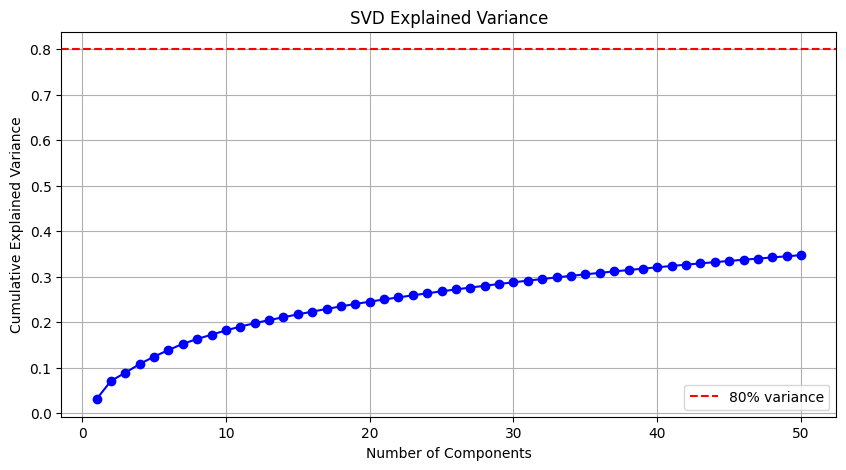

Variance explained by 50 components: 34.74%
Running t-SNE (this may take a minute)...


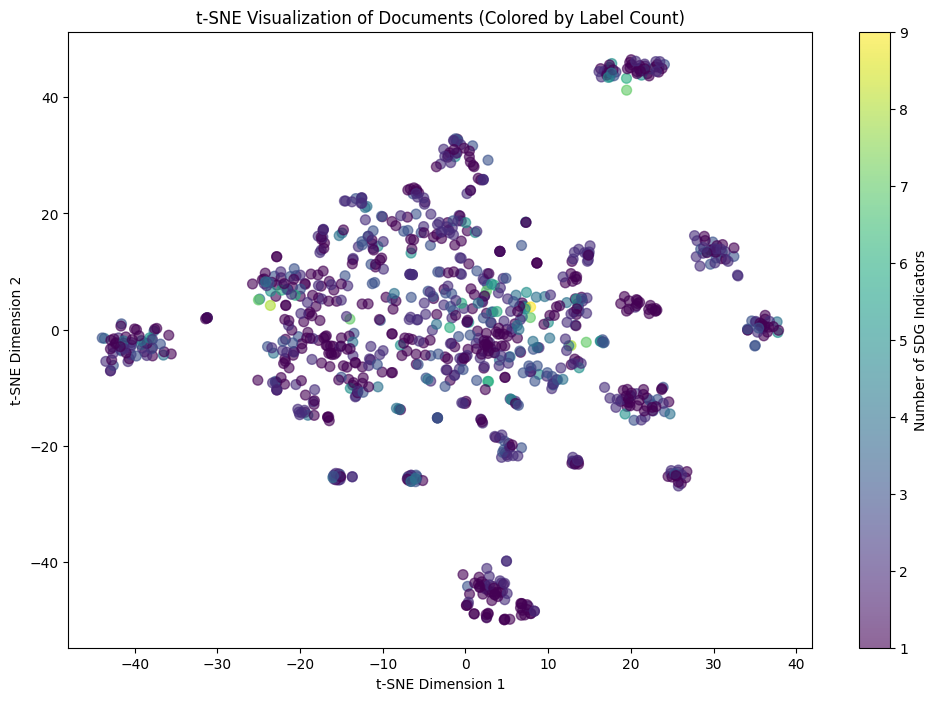

In [12]:
# ============================================
# DIMENSIONALITY REDUCTION FOR VISUALIZATION
# ============================================

print("Performing dimensionality reduction for visualization...")

# Use TruncatedSVD for TF-IDF
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf_unigram)

# Explained variance
explained_variance_ratio = svd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), cumulative_variance, 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('SVD Explained Variance')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% variance')
plt.legend()
plt.grid(True)
plt.savefig('svd_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance explained by 50 components: {cumulative_variance[-1]:.2%}")

# Further reduce to 2D with t-SNE (sample for speed)
sample_size = min(1000, len(train_df))
sample_indices = np.random.choice(len(train_df), sample_size, replace=False)
X_sample = X_svd[sample_indices]
labels_sample = labels_per_sample[sample_indices]

print("Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Create visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_sample, cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Number of SDG Indicators')
plt.title('t-SNE Visualization of Documents (Colored by Label Count)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================
# EXPERIMENT TRACKING SYSTEM
# ============================================

import json
from datetime import datetime

class ExperimentTracker:
    """Centralized experiment tracking for the team"""

    def __init__(self):
        self.experiments = []
        self.results = []

    def register_experiment(self, exp_id, name, description, parameters):
        """Register a new experiment"""
        experiment = {
            'id': exp_id,
            'name': name,
            'description': description,
            'parameters': parameters,
            'timestamp': datetime.now().isoformat(),
            'status': 'registered'
        }
        self.experiments.append(experiment)
        return experiment

    def log_result(self, exp_id, metrics, predictions=None, model_info=None):
        """Log results for an experiment"""
        result = {
            'experiment_id': exp_id,
            'metrics': metrics,
            'model_info': model_info,
            'timestamp': datetime.now().isoformat()
        }
        self.results.append(result)
        return result

    def get_comparison_table(self):
        """Generate comparison table of all experiments"""
        comparison = []
        for exp in self.experiments:
            exp_results = [r for r in self.results if r['experiment_id'] == exp['id']]
            if exp_results:
                latest = exp_results[-1]
                comparison.append({
                    'Experiment ID': exp['id'],
                    'Name': exp['name'],
                    'Hamming Loss': latest['metrics'].get('hamming_loss', 'N/A'),
                    'Precision (macro)': latest['metrics'].get('precision_macro', 'N/A'),
                    'Recall (macro)': latest['metrics'].get('recall_macro', 'N/A'),
                    'F1 (macro)': latest['metrics'].get('f1_macro', 'N/A'),
                })
        return pd.DataFrame(comparison)

    def save_to_csv(self, filename='experiment_results.csv'):
        """Save experiment results to CSV"""
        df = self.get_comparison_table()
        df.to_csv(filename, index=False)
        print(f" Experiment results saved to {filename}")
        return df

    def save_json(self, filename='experiment_tracking.json'):
        """Save complete tracking data to JSON"""
        data = {
            'experiments': self.experiments,
            'results': self.results,
            'dataset_info': {
                'n_samples': len(train_df),
                'n_indicators': len(SDG_INDICATORS),
                'avg_labels_per_doc': float(labels_per_sample.mean())
            }
        }
        with open(filename, 'w') as f:
            json.dump(data, f, indent=2)
        print(f" Tracking data saved to {filename}")

# Initialize the tracker
tracker = ExperimentTracker()

# Pre-register the planned experiments
planned_experiments = [
    (1, "Baseline TF-IDF + LR", "Simple logistic regression with unigram TF-IDF",
     {"vectorizer": "TF-IDF unigram", "model": "Logistic Regression", "max_features": 5000}),

    (2, "TF-IDF with Bigrams", "Adding bigram features to capture phrases",
     {"vectorizer": "TF-IDF bigram", "model": "Logistic Regression", "max_features": 5000}),

    (3, "Lemmatization Impact", "Using lemmatization instead of raw text",
     {"preprocessing": "lemmatization", "vectorizer": "TF-IDF unigram", "model": "Logistic Regression"}),

    (4, "Random Forest Baseline", "Compare LR vs Random Forest performance",
     {"vectorizer": "TF-IDF bigram", "model": "Random Forest", "n_estimators": 100}),

    (5, "SVM with Linear Kernel", "Testing SVM for multi-label classification",
     {"vectorizer": "TF-IDF bigram", "model": "LinearSVM", "C": 1.0}),

    (6, "Class Weighted LR", "Addressing class imbalance with class weights",
     {"vectorizer": "TF-IDF bigram", "model": "Logistic Regression", "class_weight": "balanced"}),
]

for exp in planned_experiments:
    tracker.register_experiment(*exp)

print(f" Registered {len(planned_experiments)} planned experiments")
print("\n Experiment Tracking System Ready!")
print("   Member B and C can now run experiments and log results using tracker.log_result()")

 Registered 6 planned experiments

 Experiment Tracking System Ready!
   Member B and C can now run experiments and log results using tracker.log_result()


In [14]:
# ============================================
# SAVE PROCESSED DATA
# ============================================

# Create output directory in Drive
output_dir = '/content/drive/MyDrive/SDG/'
!mkdir -p {output_dir}
!mkdir -p {output_dir}features
!mkdir -p {output_dir}visualizations

# Save processed DataFrame
train_df.to_csv(f'{output_dir}train_processed.csv', index=False)
test_df.to_csv(f'{output_dir}test_raw.csv', index=False)

# Save feature matrices
import scipy.sparse as sp
sp.save_npz(f'{output_dir}features/X_tfidf_unigram.npz', X_tfidf_unigram)
sp.save_npz(f'{output_dir}features/X_tfidf_bigram.npz', X_tfidf_bigram)
sp.save_npz(f'{output_dir}features/X_tfidf_trigram.npz', X_tfidf_trigram)

# Save labels
y_labels = train_df[SDG_INDICATORS].values
np.save(f'{output_dir}features/y_labels.npy', y_labels)
np.save(f'{output_dir}features/indicator_names.npy', np.array(SDG_INDICATORS))

# Save vectorizers
import pickle
with open(f'{output_dir}features/vectorizer_unigram.pkl', 'wb') as f:
    pickle.dump(vectorizer_unigram, f)
with open(f'{output_dir}features/vectorizer_bigram.pkl', 'wb') as f:
    pickle.dump(vectorizer_bigram, f)
with open(f'{output_dir}features/vectorizer_trigram.pkl', 'wb') as f:
    pickle.dump(vectorizer_trigram, f)

# Save preprocessor objects
with open(f'{output_dir}features/preprocessor_standard.pkl', 'wb') as f:
    pickle.dump(preprocessor_standard, f)

# Save experiment tracker
tracker.save_json(f'{output_dir}experiment_tracking.json')

# Save visualizations to Drive
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
label_counts.head(20).plot(kind='barh', color='steelblue')
plt.xlabel('Number of Samples')
plt.title('SDG Indicator Distribution')
plt.tight_layout()
plt.savefig(f'{output_dir}visualizations/label_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

print("\n" + "=" * 60)
print(" ALL FILES SAVED TO GOOGLE DRIVE!")
print("=" * 60)
print(f"\n Location: {output_dir}")
print("\nFiles saved:")
print("   train_processed.csv")
print("   test_raw.csv")
print("   features/ (all feature matrices, labels, vectorizers)")
print("   visualizations/ (EDA plots)")
print("   experiment_tracking.json")

 Tracking data saved to /content/drive/MyDrive/SDG/experiment_tracking.json

 ALL FILES SAVED TO GOOGLE DRIVE!

 Location: /content/drive/MyDrive/SDG/

Files saved:
   train_processed.csv
   test_raw.csv
   features/ (all feature matrices, labels, vectorizers)
   visualizations/ (EDA plots)
   experiment_tracking.json


In [15]:
# ============================================
# TEAM SUMMARY REPORT
# ============================================

from datetime import datetime

summary_report = f"""
{'='*60}
SDG CLASSIFICATION PROJECT - DATA PIPELINE REPORT
{'='*60}
Generated by: Member A (Data Pipeline Lead)
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

{'DATASET SUMMARY':^60}
{'-'*60}
- Training samples: {len(train_df)}
- Test samples: {len(test_df)}
- SDG 3 indicators: {len(SDG_INDICATORS)}
- Average labels per document: {labels_per_sample.mean():.2f}
- Documents with multiple labels: {(labels_per_sample >= 2).sum()} ({(labels_per_sample >= 2).sum()/len(train_df)*100:.1f}%)

{'KEY EDA FINDINGS':^60}
{'-'*60}
 Class Imbalance: Some indicators have very few samples
 Label Correlation: {len([p for p in corr_pairs[:5] if p[2] > 0.5])} pairs have correlation > 0.5
Text Length: Average {train_df['word_count'].mean():.0f} words per document

{'PREPROCESSING':^60}
{'-'*60}
- Created 3 preprocessing variants (basic, standard, aggressive)
- Standard preprocessing includes: lowercase, punctuation removal, stopword removal, lemmatization
- Domain-specific stopwords added for SDG texts

{'FEATURES CREATED':^60}
{'-'*60}
- TF-IDF unigram: {X_tfidf_unigram.shape}
- TF-IDF bigram: {X_tfidf_bigram.shape}
- TF-IDF trigram: {X_tfidf_trigram.shape}

{'EXPERIMENTS REGISTERED':^60}
{'-'*60}
{len(planned_experiments)} experiments pre-registered in tracking system:
{chr(10).join([f'  Exp {e[0]}: {e[1]}' for e in planned_experiments])}

{'FILES LOCATION':^60}
{'-'*60}
 Google Drive: {output_dir}

{'INSTRUCTIONS FOR TEAM MEMBERS':^60}
{'-'*60}

 Member B (Modeling & Experiments):
   - Use: {output_dir}features/X_tfidf_bigram.npz
   - Use: {output_dir}features/y_labels.npy
   - Load with: scipy.sparse.load_npz()

 Member C (Feature Engineering & Tuning):
   - Use: {output_dir}features/preprocessor_standard.pkl
   - Experiment with different preprocessing configs
   - Try embedding alternatives

 Member D (Results & Evaluation):
   - Load: {output_dir}experiment_tracking.json
   - Track all experiment results
   - Generate comparison tables

{'NEXT STEPS':^60}
{'-'*60}
1.  Share this Drive folder with your team
2.  Member B: Start baseline experiments
3.  Member C: Begin feature tuning
4.  Member D: Setup evaluation framework

{'='*60}
"""

print(summary_report)

# Save summary report to Drive
with open(f'{output_dir}PIPELINE_SUMMARY.txt', 'w') as f:
    f.write(summary_report)

print(f"\n Summary report saved to: {output_dir}PIPELINE_SUMMARY.txt")
print("\n🔗 Share this Google Drive folder with your team members!")


SDG CLASSIFICATION PROJECT - DATA PIPELINE REPORT
Generated by: Member A (Data Pipeline Lead)
Date: 2026-06-06 16:44:12

                      DATASET SUMMARY                       
------------------------------------------------------------
- Training samples: 2995
- Test samples: 998
- SDG 3 indicators: 27
- Average labels per document: 1.97
- Documents with multiple labels: 1633 (54.5%)

                      KEY EDA FINDINGS                      
------------------------------------------------------------
 Class Imbalance: Some indicators have very few samples
 Label Correlation: 2 pairs have correlation > 0.5
Text Length: Average 478 words per document

                       PREPROCESSING                        
------------------------------------------------------------
- Created 3 preprocessing variants (basic, standard, aggressive)
- Standard preprocessing includes: lowercase, punctuation removal, stopword removal, lemmatization
- Domain-specific stopwords added for SDG te

In [16]:
# ============================================
# VERIFY ALL FILES WERE SAVED CORRECTLY
# ============================================

print("Verifying saved files...")
print("=" * 60)

import os

files_to_check = [
    f'{output_dir}train_processed.csv',
    f'{output_dir}test_raw.csv',
    f'{output_dir}features/X_tfidf_bigram.npz',
    f'{output_dir}features/y_labels.npy',
    f'{output_dir}features/vectorizer_bigram.pkl',
    f'{output_dir}features/preprocessor_standard.pkl',
    f'{output_dir}experiment_tracking.json',
]

all_exist = True
for filepath in files_to_check:
    exists = os.path.exists(filepath)
    status = "" if exists else ""
    print(f"{status} {os.path.basename(filepath)}: {'Found' if exists else 'MISSING'}")
    if not exists:
        all_exist = False

if all_exist:
    print("\n" + "=" * 60)
    print("🎉 ALL FILES SUCCESSFULLY SAVED!")
    print("=" * 60)
    print("\n📧 Share this Drive link with your team:")
    print(f"   {output_dir}")
else:
    print("\n⚠️ Some files are missing. Check the save operations above.")

Verifying saved files...
 train_processed.csv: Found
 test_raw.csv: Found
 X_tfidf_bigram.npz: Found
 y_labels.npy: Found
 vectorizer_bigram.pkl: Found
 preprocessor_standard.pkl: Found
 experiment_tracking.json: Found

🎉 ALL FILES SUCCESSFULLY SAVED!

📧 Share this Drive link with your team:
   /content/drive/MyDrive/SDG/


In [17]:
# ============================================
# PREPROCESS TEST SET FOR  MEMBERS
# ============================================

print("Preprocessing test set...")

# Apply standard preprocessing to test set
test_df['text_clean_standard'] = test_df[TEXT_COL].apply(preprocessor_standard.preprocess)

# Transform test set using the same vectorizers
X_test_tfidf_unigram = vectorizer_unigram.transform(test_df['text_clean_standard'])
X_test_tfidf_bigram = vectorizer_bigram.transform(test_df['text_clean_standard'])
X_test_tfidf_trigram = vectorizer_trigram.transform(test_df['text_clean_standard'])

print(f" Test set unigram shape: {X_test_tfidf_unigram.shape}")
print(f" Test set bigram shape: {X_test_tfidf_bigram.shape}")
print(f"Test set trigram shape: {X_test_tfidf_trigram.shape}")

# Save test features
sp.save_npz(f'{output_dir}features/X_test_tfidf_unigram.npz', X_test_tfidf_unigram)
sp.save_npz(f'{output_dir}features/X_test_tfidf_bigram.npz', X_test_tfidf_bigram)
sp.save_npz(f'{output_dir}features/X_test_tfidf_trigram.npz', X_test_tfidf_trigram)

# Save test unique IDs for reference
test_df['Unique ID'].to_csv(f'{output_dir}test_ids.csv', index=False)

print("\nTest set preprocessing complete!")
print(f"   Saved to: {output_dir}features/X_test_*.npz")

Preprocessing test set...
 Test set unigram shape: (998, 5000)
 Test set bigram shape: (998, 5000)
Test set trigram shape: (998, 5000)

Test set preprocessing complete!
   Saved to: /content/drive/MyDrive/SDG/features/X_test_*.npz
